# Load Stuff

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

import joblib

In [2]:
df=pd.read_csv("train.csv")
df

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,Male,NaN,No,1
691365,691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,Female,High,No,1
691366,691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,Other,Medium,No,1
691367,691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,Other,NaN,NaN,1


In [3]:
X_test=pd.read_csv("test.csv")
X_test

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact
0,691369,30.0,9.34,NaN,0.77,4.09,7.15,153.0,16.0,NaN,Other,Medium,Yes
1,691370,NaN,NaN,1.91,NaN,1.20,8.67,239.0,148.0,10.68,Female,High,No
2,691371,26.0,8.48,3.64,NaN,3.39,7.47,106.0,123.0,NaN,Male,NaN,No
3,691372,20.0,8.37,2.99,1.69,2.53,5.45,178.0,55.0,9.88,Male,High,Yes
4,691373,25.0,8.25,4.02,1.21,2.32,8.46,63.0,86.0,10.72,Male,Low,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
296297,987666,25.0,11.76,5.15,1.94,2.75,8.24,237.0,127.0,14.10,Male,NaN,NaN
296298,987667,28.0,7.67,2.70,1.55,2.95,5.54,187.0,121.0,8.25,Male,Low,Yes
296299,987668,33.0,5.27,1.84,0.20,2.44,8.29,96.0,73.0,6.57,Female,High,No
296300,987669,NaN,NaN,1.25,0.52,0.71,6.27,57.0,38.0,7.19,Female,Low,Yes


# EDA

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  object 
 11  stress_level             636221 non-null  object 
 12  academic_work_impact     647145 non-null  object 
 13  addicted_label           691369 non-null  int64  
dtypes: f

In [5]:
df.describe()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,691369.000000,662440.000000,595515.000000,557374.000000,564548.000000,639851.000000,646889.000000,623785.000000,610659.000000,579306.000000,691369.000000
mean,345684.000000,26.615408,7.640865,2.471038,1.459265,2.366971,6.804334,145.894900,102.636781,9.479866,0.709424
std,199581.183466,5.153162,2.721446,1.316137,0.934552,1.258797,1.234512,65.917556,48.093970,2.856006,0.454028
min,0.000000,18.000000,0.500000,0.000000,0.000000,0.000000,4.500000,20.000000,15.000000,0.510000,0.000000
25%,172842.000000,22.000000,5.480000,1.450000,0.700000,1.360000,5.780000,93.000000,64.000000,7.280000,0.000000
50%,345684.000000,27.000000,7.770000,2.310000,1.330000,2.200000,6.800000,150.000000,104.000000,9.580000,1.000000
75%,518526.000000,31.000000,9.840000,3.370000,2.090000,3.200000,7.870000,204.000000,145.000000,11.750000,1.000000
max,691368.000000,35.000000,15.000000,8.000000,4.000000,6.000000,9.000000,250.000000,180.000000,17.560000,1.000000


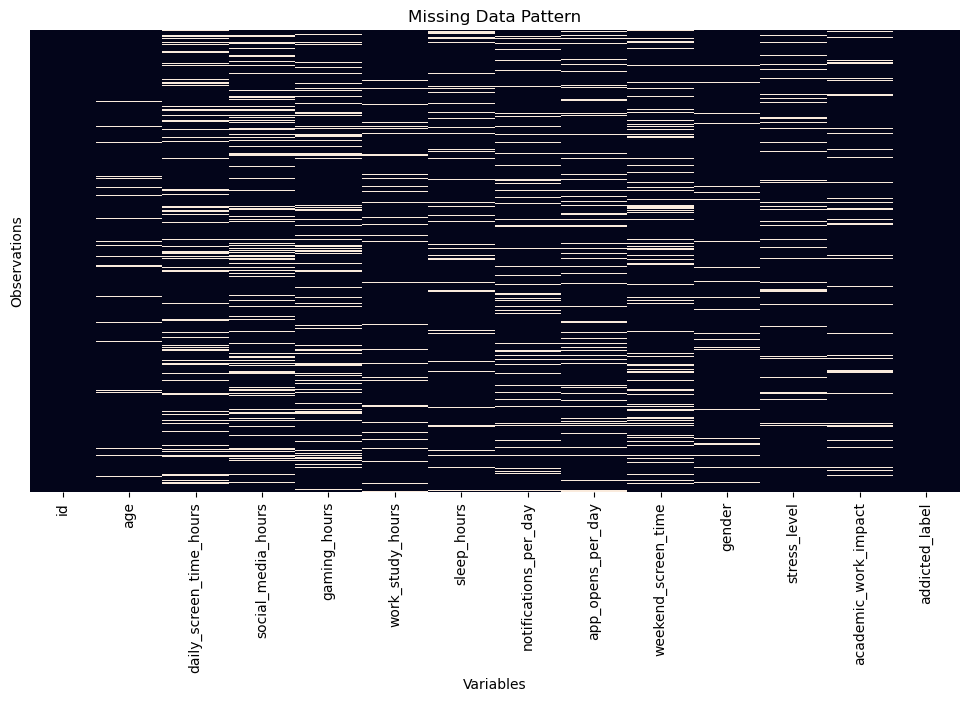

In [6]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(),cbar=False,yticklabels=False)

plt.title("Missing Data Pattern")
plt.xlabel("Variables")
plt.ylabel("Observations")
plt.show()

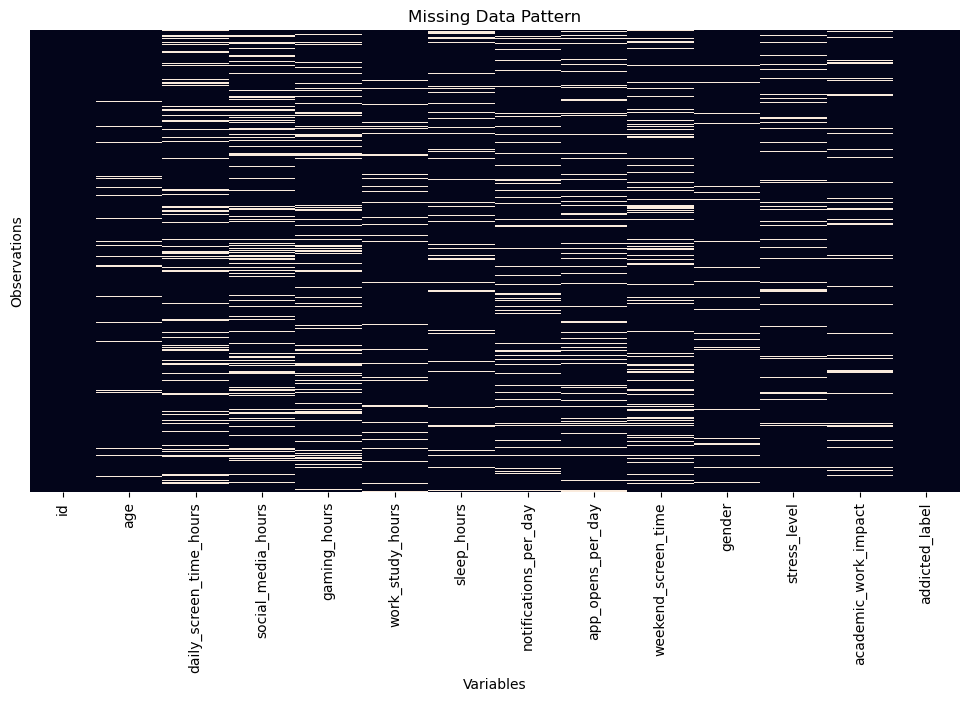

In [7]:
df=df.dropna(axis=1,thresh=5)
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(),cbar=False,yticklabels=False)

plt.title("Missing Data Pattern")
plt.xlabel("Variables")
plt.ylabel("Observations")
plt.show()

# Preprocessing

In [8]:
X_train=df.drop(columns=["id","addicted_label"])
y_train=df["addicted_label"]
testid=X_test["id"]
X_test=X_test.drop(columns=["id"])

In [9]:
def preprocessing(X:pd.DataFrame)->pd.DataFrame:
    X=pd.get_dummies(X, columns=["gender","stress_level","academic_work_impact"])
    imputer=SimpleImputer(strategy="median")
    imputer.set_output(transform="pandas")
    X=imputer.fit_transform(X)
    return X

In [10]:
X_train=preprocessing(X_train)
X_test=preprocessing(X_test)

# Logistic Regression

In [11]:
logistic=LogisticRegression(random_state=42)
logistic.fit(X_train,y_train)

joblib.dump(logistic,"models/logistic_model.joblib")

scores=cross_val_score(logistic,X_train,y_train,cv=5,scoring="roc_auc")
scores

d:\Program Files\Anaconda\envs\pytorch_new\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
d:\Program Files\Anaconda\envs\pytorch_new\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_mode

array([0.90115323, 0.89479485, 0.89355975, 0.89857023, 0.89760179])

# SVM

In [12]:
svm=make_pipeline(StandardScaler(),LinearSVC(dual="auto",random_state=42))
svm.fit(X_train,y_train)

joblib.dump(svm,"models/svm.joblib")

scores=cross_val_score(svm,X_train,y_train,cv=5,scoring="roc_auc")
scores

array([0.91226366, 0.911445  , 0.91122597, 0.91138127, 0.91168371])

# XGBoost

In [ ]:
X_train_new,y_train_new,X_valid,y_valid=train_test_split(X_train,X_test,test_size=0.1,random_state=42)

In [ ]:
dtrain = xgb.DMatrix(X_train, label=y_train)
model=xgb.XGBClassifier()
params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "max_depth": 3,
    "eta": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "seed": 42
}
model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=1000,
    early_stopping_rounds=20,
    verbose_eval=20
)

scores=cross_val_score(svm,X_train,y_train,cv=5,scoring="roc_auc")
scores

# Testing

In [13]:
model=joblib.load("models/svm.joblib")

In [14]:
y_test=model.predict(X_test)
y_test

array([1, 1, 1, ..., 0, 0, 1])

In [15]:
y_test.shape

(296302,)

In [16]:
testid.shape

(296302,)

In [17]:
submission=np.stack((testid,y_test), axis=1)
submission

array([[691369,      1],
       [691370,      1],
       [691371,      1],
       ...,
       [987668,      0],
       [987669,      0],
       [987670,      1]])

In [18]:
submission=pd.DataFrame(submission)
submission

,0,1
0,691369,1
1,691370,1
2,691371,1
3,691372,1
4,691373,1
...,...,...
296297,987666,1
296298,987667,1
296299,987668,0
296300,987669,0


In [19]:
submission.columns = ['id', 'addicted_label']

In [20]:
submission.to_csv("submission.csv", index=False)